<a href="https://colab.research.google.com/github/alt-gabby/QuantumColab/blob/main/Assignment_1_QML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 139.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 143.9 MB/s eta 0:00:00


# Two-qubit state (Bipartite entanglement)

Target state:  $$
|\psi_p\rangle = \sqrt{p} |00\rangle + \sqrt{1-p} |11\rangle
$$

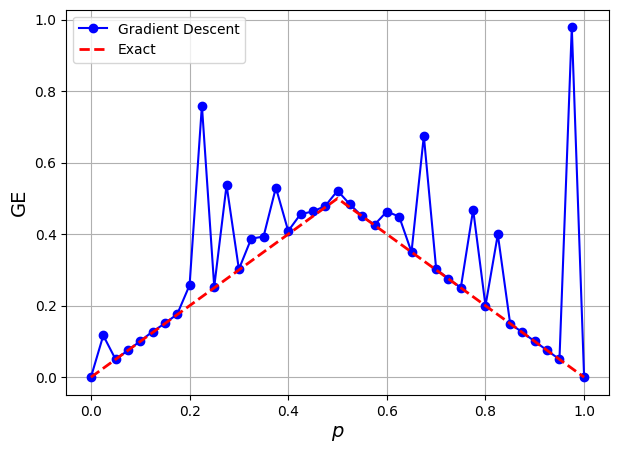

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Quantum device
# -----------------------------
dev = qml.device("default.qubit", wires=2)

# -----------------------------
# Variational separable state
# -----------------------------
@qml.qnode(dev, interface="autograd")
def rotate_x_z(params):
    phi1, beta1, phi2, beta2 = params

    # qubit A
    qml.RX(phi1, wires=0)
    qml.RZ(beta1, wires=0)

    # qubit B
    qml.RX(phi2, wires=1)
    qml.RZ(beta2, wires=1)

    return qml.state()

# -----------------------------
# Target state
# -----------------------------
def psi_p(p):
    return np.array(
        [np.sqrt(p), 0, 0, np.sqrt(1 - p)],
        requires_grad=False
    )

# -----------------------------
# Cost function
# -----------------------------
def cost(params, psi):
    state = rotate_x_z(params)

    overlap = np.sum(np.conj(psi) * state)

    fidelity = overlap * np.conj(overlap)

    return 1 - np.real(fidelity)

# -----------------------------
# Gradient descent optimization
# -----------------------------
def gradient_descent_GE(p, steps=200, lr=0.1):

    psi = psi_p(p)

    params = np.random.uniform(
        0,
        2*np.pi,
        4,
        requires_grad=True
    )

    for _ in range(steps):

        grads = qml.grad(cost)(params, psi)

        params = params - lr * grads

    loss = cost(params, psi)

    return loss

# -----------------------------
# Evaluate GE over p values
# -----------------------------
p_values = np.linspace(0, 1, 41)

ge_values = []

for p in p_values:

    best_loss= gradient_descent_GE(
        p,
        steps=300,
        lr=0.05
    )

    ge_values.append(best_loss)

# -----------------------------
# Exact result
# -----------------------------
ge_exact = np.minimum(p_values, 1 - p_values)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(
    p_values,
    ge_values,
    'bo-',
    label='Gradient Descent'
)

plt.plot(
    p_values,
    ge_exact,
    'r--',
    linewidth=2,
    label='Exact'
)

plt.xlabel(r"$p$", fontsize=14)
plt.ylabel("GE", fontsize=14)

plt.grid()
plt.legend()
plt.show()

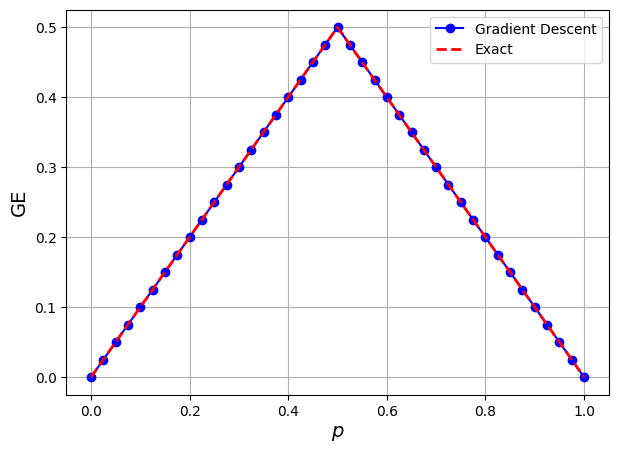

In [ ]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Quantum device
# -----------------------------
dev = qml.device("default.qubit", wires=2)

# -----------------------------
# Variational separable state
# -----------------------------
@qml.qnode(dev, interface="autograd")
def rotate_x_z(params):
    phi1, beta1, phi2, beta2 = params

    # qubit A
    qml.RX(phi1, wires=0)
    qml.RZ(beta1, wires=0)

    # qubit B
    qml.RX(phi2, wires=1)
    qml.RZ(beta2, wires=1)

    return qml.state()

# -----------------------------
# Target state
# -----------------------------
def psi_p(p):
    return np.array(
        [np.sqrt(p), 0, 0, np.sqrt(1 - p)],
        requires_grad=False
    )

# -----------------------------
# Cost function
# -----------------------------
def cost(params, psi):
    state = rotate_x_z(params)

    overlap = np.sum(np.conj(psi) * state)

    fidelity = overlap * np.conj(overlap)

    return 1 - np.real(fidelity)

# -----------------------------
# Gradient descent optimization
# -----------------------------
def gradient_descent_GE(p, steps=200, lr=0.1):

    psi = psi_p(p)

    # random initial parameters
    params = np.random.uniform(
        0, 2*np.pi, 4,
        requires_grad=True
    )

    opt = qml.AdamOptimizer(stepsize=lr)

    for _ in range(steps):

        params, loss = opt.step_and_cost(
            lambda v: cost(v, psi),
            params
        )

    return loss

# -----------------------------
# Evaluate GE over p values
# -----------------------------
p_values = np.linspace(0, 1, 41)

ge_values = []

for p in p_values:

    best_loss= gradient_descent_GE(
        p,
        steps=300,
        lr=0.05
    )

    ge_values.append(best_loss)

# -----------------------------
# Exact result
# -----------------------------
ge_exact = np.minimum(p_values, 1 - p_values)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(7,5))

plt.plot(
    p_values,
    ge_values,
    'bo-',
    label='Gradient Descent'
)

plt.plot(
    p_values,
    ge_exact,
    'r--',
    linewidth=2,
    label='Exact'
)

plt.xlabel(r"$p$", fontsize=14)
plt.ylabel("GE", fontsize=14)

plt.grid()
plt.legend()
plt.show()

# **Exercise**: Find the ground state energy of
$$H=JZ\otimes Z+b_1X\otimes I+b_2I\otimes X$$

First i write out the hamiltonian in code.
ZZ term couples the two qubits, and the X terms act on each qubit individually. These compete with each other, which is what makes the ground state entangled.
I'll set J=b1=b2=1J = b_1 = b_2 = 1
J=b1​=b2​=1 simplicity.
---



In [ ]:
J=1
b1=1
b2=1

In [ ]:
H = qml.Hamiltonian(
    [J, b1, b2],
    [qml.PauliZ(0) @ qml.PauliZ(1),
     qml.PauliX(0),
     qml.PauliX(1)]
)

Pick an ansatz that can create entangled states. So i need a CNOT. so it gives 6 parameters in total



In [ ]:
@qml.qnode(dev)
def circuit(params):
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[2], wires=0)
    qml.RY(params[3], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RY(params[4], wires=0)
    qml.RY(params[5], wires=1)
    return qml.expval(H)

Here i dont know the target state so i use the variational principle Eq. 10 in the lecture, minimizing the hamiltonian expectation value gives an upper bound on the ground state energy. The circuit alreafy gives quml.expval(H)

So initial parameters one for each Ry.

In [ ]:
params = np.random.uniform(0, 2*np.pi, 6, requires_grad=True)

Optimization iwith a classical optimizer. I use Adam as opposed to plain gradient descent.
At each step:

The circuit computes the Hamiltonian expectation value.
PennyLane computes gradients with the parameter-shift rule
Adam updates the parameters to lower the energy
I save the energy at each step in energy_history so I can plot the convergence.


In [ ]:
opt = qml.AdamOptimizer(stepsize=0.1)
energy_history = []
for i in range(200):
    params, energy = opt.step_and_cost(circuit, params)
    energy_history.append(energy)
    if i % 20 == 0:
        print(f"Step {i:3d}:  E = {energy:.6f}")

print(f"\nFinal VQE energy: {circuit(params):.6f}")

Step   0:  E = -2.236062
Step  20:  E = -2.227721
Step  40:  E = -2.236021
Step  60:  E = -2.236056
Step  80:  E = -2.236045
Step 100:  E = -2.236066
Step 120:  E = -2.236068
Step 140:  E = -2.236068
Step 160:  E = -2.236068
Step 180:  E = -2.236068

Final VQE energy: -2.236068


The Hamiltonian is only a 4×4 matrix, so I can diagonalize it directly with NumPy and compare. For real problems with many qubits it wouldnt work but thats where VQE come in.
For J=b1​=b2​=1, the exact ground state energy is E_0 =\approx -2.2361


VQE ground state energy:   -2.236062
Exact ground state energy: -2.236068
Absolute error:            5.49e-06


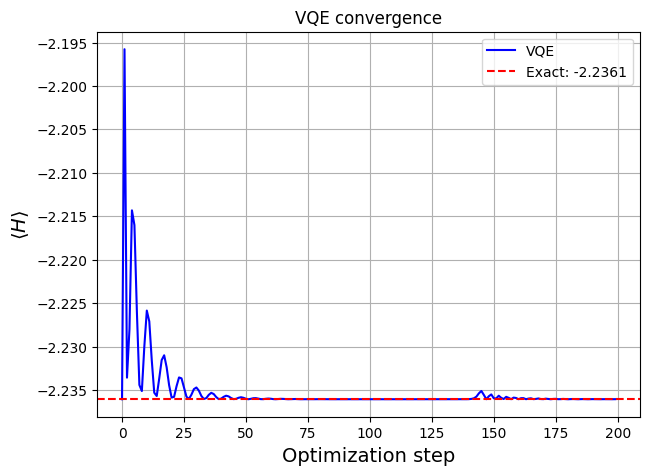

In [ ]:
# Define Pauli matrices
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

# Exact diagonalization
H_matrix = J*np.kron(Z, Z) + b1*np.kron(X, I) + b2*np.kron(I, X)
E_exact = np.linalg.eigvalsh(H_matrix)[0]

# VQE result
E_vqe = circuit(params)

# Print the answer
print(f"VQE ground state energy:   {E_vqe:.6f}")
print(f"Exact ground state energy: {E_exact:.6f}")
print(f"Absolute error:            {abs(E_vqe - E_exact):.2e}")

# Plot convergence (like the example in the lab)
plt.figure(figsize=(7, 5))
plt.plot(energy_history, 'b-', label='VQE')
plt.axhline(E_exact, color='r', linestyle='--', label=f'Exact: {E_exact:.4f}')
plt.xlabel("Optimization step", fontsize=14)
plt.ylabel(r"$\langle H \rangle$", fontsize=14)
plt.title("VQE convergence")
plt.legend()
plt.grid()
plt.show()